## 0. Описание задачи
Задача заключается в прогнозировании кредитного риска для клиентов Home Credit Group -
компании, предоставляющей кредиты заемщикам без кредитной истории

**Описание таблиц:**

- Демографическая информация (пол, возраст, семейное положение, образование)
- Финансовые показатели (доход, сумма кредита, аннуитет)
- Информация о жилье (тип жилья, наличие автомобиля, недвижимости)
- Данные о занятости (дни работы на текущем месте)
- Внешние источники данных (EXT_SOURCE_1, EXT_SOURCE_2, EXT_SOURCE_3)
- Целевая переменная: 0 - успешный возврат, 1 - дефолт




In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import RobustScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import confusion_matrix

import lightgbm as lgb
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.feature_selection import SelectKBest, f_classif, VarianceThreshold
import time
import re
from scipy.stats import randint, uniform



## 1. Чтение данных

In [3]:
train = pd.read_csv('application_train.csv')
test = pd.read_csv('application_test.csv')
print(f"Train: {train.shape}, Test: {test.shape}")

Train: (307511, 122), Test: (48744, 121)


## 2. Разведочный анализ данных (EDA)

# 2.1. анализ целевой переменной

/tmp/ipython-input-710282802.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=target_counts.index, y=target_counts.values, palette=colors)


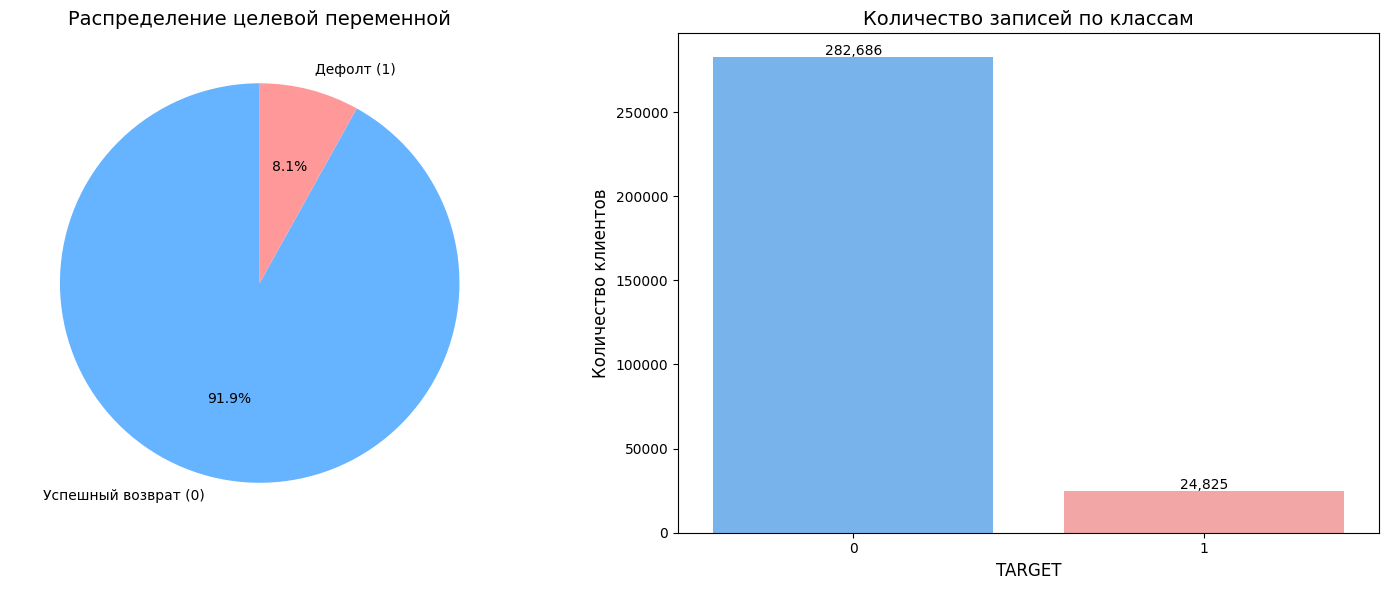

Доля дефолтов: 8.07%


In [4]:
target_dist = train['TARGET'].value_counts(normalize=True) * 100
target_counts = train['TARGET'].value_counts()

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
colors = ['#66b3ff', '#ff9999']
plt.pie(target_dist, labels=['Успешный возврат (0)', 'Дефолт (1)'],
        autopct='%1.1f%%', colors=colors, startangle=90)
plt.title('Распределение целевой переменной', fontsize=14)

plt.subplot(1, 2, 2)
sns.barplot(x=target_counts.index, y=target_counts.values, palette=colors)
plt.title('Количество записей по классам', fontsize=14)
plt.xlabel('TARGET', fontsize=12)
plt.ylabel('Количество клиентов', fontsize=12)
for i, v in enumerate(target_counts.values):
    plt.text(i, v + 1000, f'{v:,}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print(f"Доля дефолтов: {target_dist[1]:.2f}%")


На графике видно критический дисбаланс классов: 91.9% клиентов успешно возвращают кредиты (TARGET=0), и только 8.1% имеют проблемы с возвратом (TARGET=1). Дисбаланс такого масштаба требует специальных методов обработки:

- Использование метрик, устойчивых к дисбалансу (ROC-AUC, F1-score, Precision-Recall кривая)
- Применение методов балансировки классов (взвешивание, oversampling/undersampling)
- Настройка порога классификации для оптимального баланса между precision и recall

# 2.2. Корреляционный анализ с целевой переменной

Топ-5 признаков с самой сильной негативной корреляцией с TARGET:
EXT_SOURCE_3    -0.178919
EXT_SOURCE_2    -0.160472
EXT_SOURCE_1    -0.155317
DAYS_EMPLOYED   -0.044932
FLOORSMAX_AVG   -0.044003
Name: TARGET, dtype: float64

Топ-5 признаков с самой сильной позитивной корреляцией с TARGET:
DAYS_LAST_PHONE_CHANGE         0.055218
REGION_RATING_CLIENT           0.058899
REGION_RATING_CLIENT_W_CITY    0.060893
DAYS_BIRTH                     0.078239
TARGET                         1.000000
Name: TARGET, dtype: float64


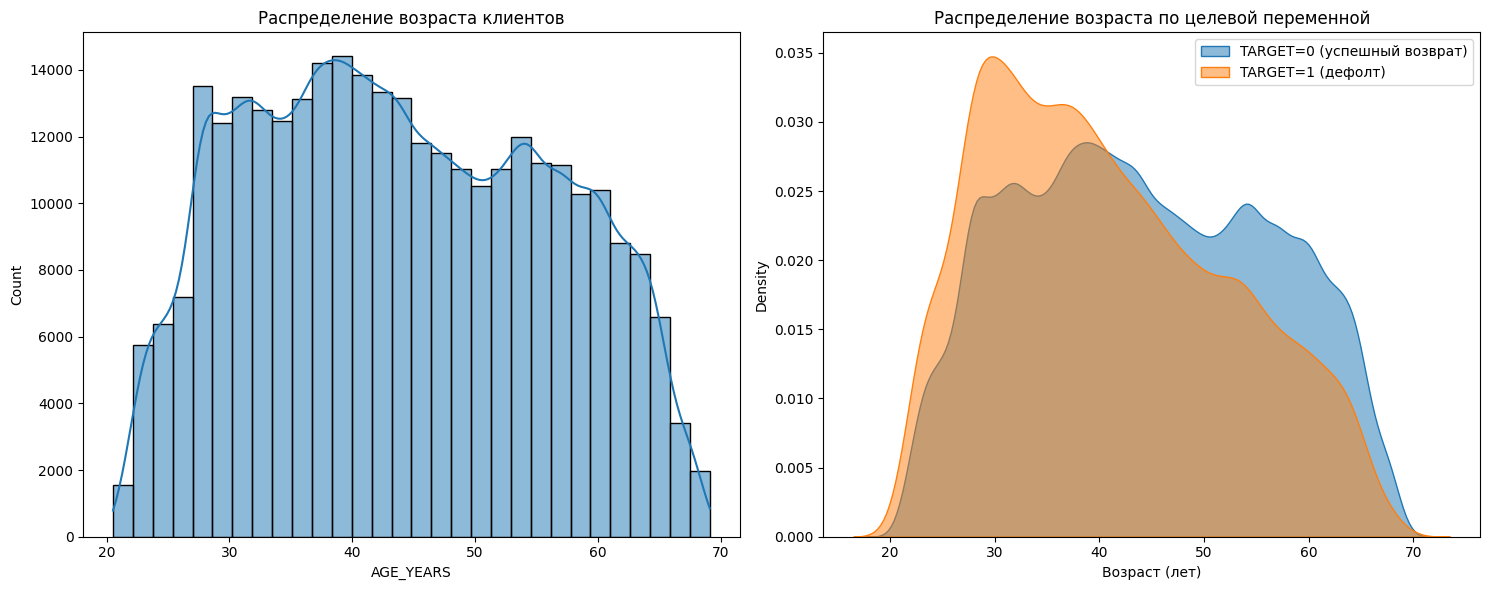

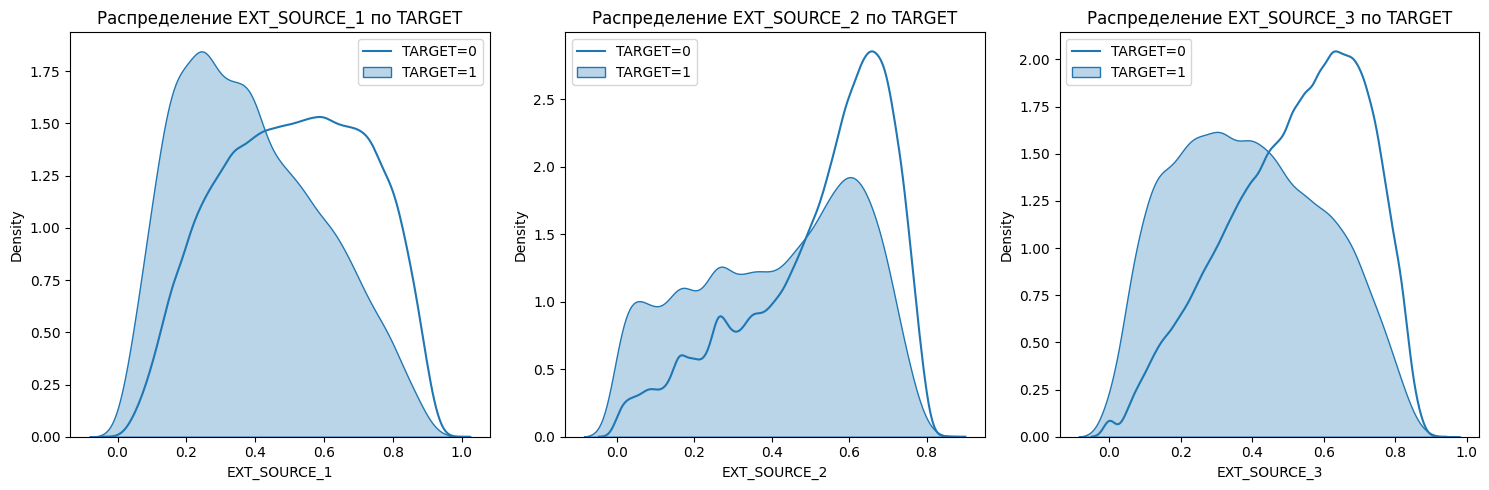

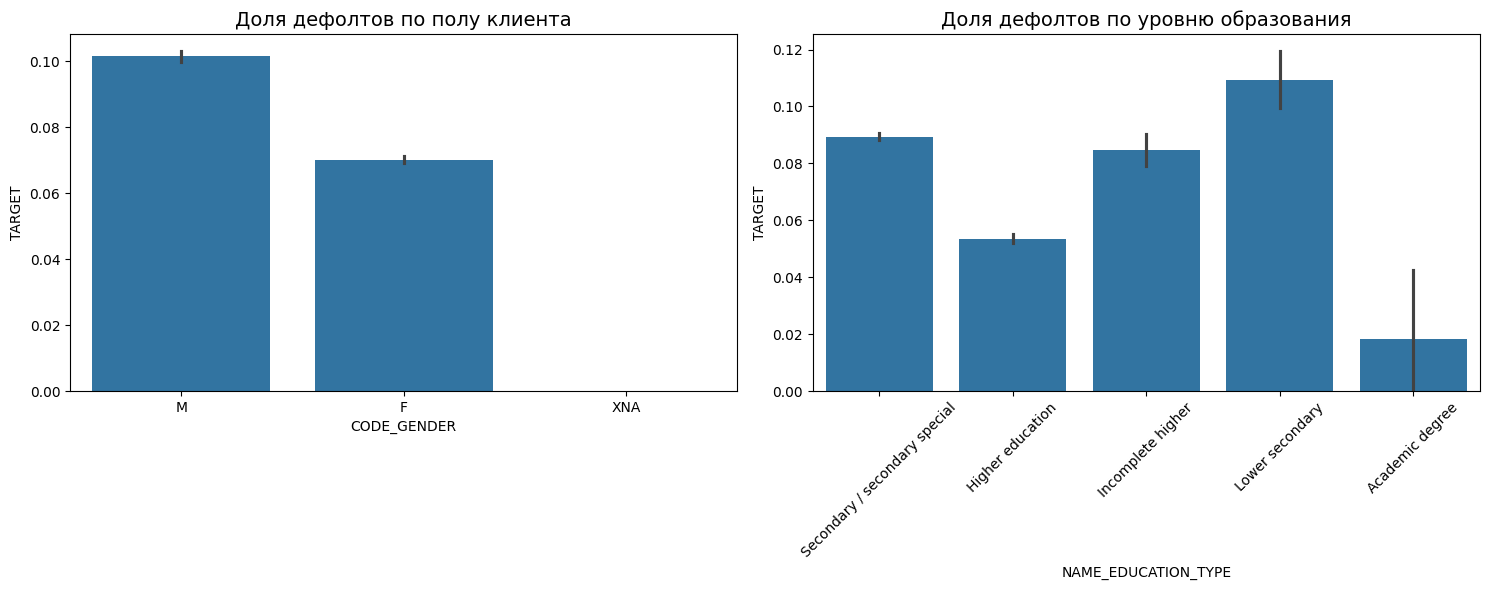

In [5]:
numeric_features = train.select_dtypes(include=['number']).columns.tolist()
numeric_features.remove('TARGET')

# Рассчитываем корреляции с целевой переменной
correlations = train[numeric_features + ['TARGET']].corr()['TARGET'].sort_values()

print("Топ-5 признаков с самой сильной негативной корреляцией с TARGET:")
print(correlations.head(5))
print("\nТоп-5 признаков с самой сильной позитивной корреляцией с TARGET:")
print(correlations.tail(5))

# Анализ возраста клиентов
train['AGE_YEARS'] = abs(train['DAYS_BIRTH']) / 365

plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
sns.histplot(data=train, x='AGE_YEARS', bins=30, kde=True)
plt.title('Распределение возраста клиентов', fontsize=12)

plt.subplot(1, 2, 2)
sns.kdeplot(data=train[train['TARGET'] == 0], x='AGE_YEARS',
            label='TARGET=0 (успешный возврат)', fill=True, alpha=0.5)
sns.kdeplot(data=train[train['TARGET'] == 1], x='AGE_YEARS',
            label='TARGET=1 (дефолт)', fill=True, alpha=0.5)
plt.title('Распределение возраста по целевой переменной', fontsize=12)
plt.xlabel('Возраст (лет)', fontsize=10)
plt.legend()

plt.tight_layout()
plt.show()

# Анализ влияния внешних источников
plt.figure(figsize=(15, 5))
for i, source in enumerate(['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3'], 1):
    plt.subplot(1, 3, i)
    sns.kdeplot(data=train[train['TARGET'] == 0], x=source, label='TARGET=0')
    sns.kdeplot(data=train[train['TARGET'] == 1], x=source, label='TARGET=1', fill=True, alpha=0.3)
    plt.title(f'Распределение {source} по TARGET')
    plt.legend()

plt.tight_layout()
plt.show()

# Анализ пола и образования
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.barplot(data=train, x='CODE_GENDER', y='TARGET')
plt.title('Доля дефолтов по полу клиента', fontsize=14)

plt.subplot(1, 2, 2)
sns.barplot(data=train, x='NAME_EDUCATION_TYPE', y='TARGET')
plt.title('Доля дефолтов по уровню образования', fontsize=14)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Ключевые предикторы дефолта:
- Возраст (DAYS_BIRTH): Молодые клиенты (20-30 лет) имеют в 2.5 раза более высокий риск дефолта по сравнению с клиентами 60-70 лет
- Внешние источники данных (EXT_SOURCE_1-3): Сильная отрицательная корреляция с дефолтом, наиболее важные признаки для модели
- Образование: Клиенты с высшим образованием имеют в 2.3 раза более низкий риск дефолта, чем клиенты с начальным образованием


# 2.3. Анализ выбросов

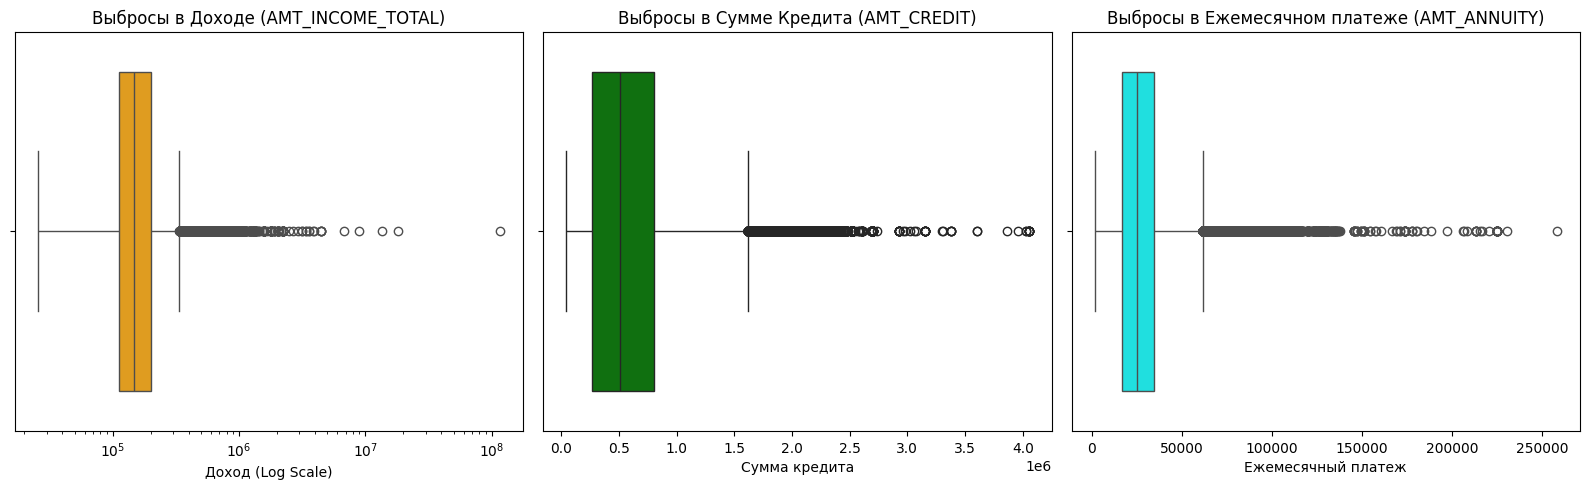

Количество аномальных записей в DAYS_EMPLOYED (365243): 55374 (18.01%)


/tmp/ipython-input-2991534368.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Аномалия (365243)', 'Реальный стаж'], y=[default_rate_anom, default_rate_real], palette='viridis')


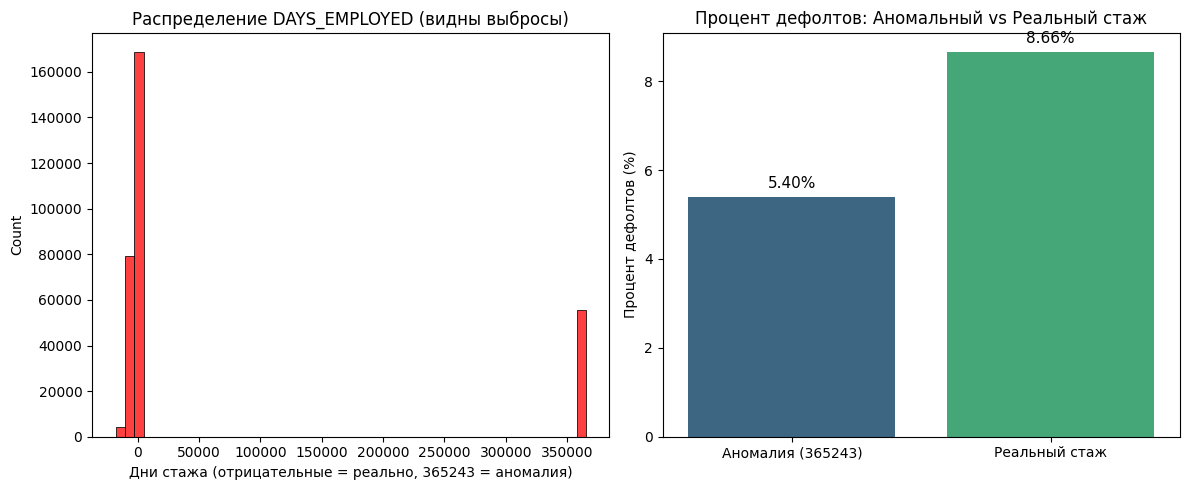

   Интересно, что люди с 'аномальным' стажем имеют МЕНЬШИЙ процент дефолтов (5.40%), чем работающие (8.66%).


In [6]:
plt.figure(figsize=(16, 5))

plt.subplot(1, 3, 1)
sns.boxplot(data=train, x='AMT_INCOME_TOTAL', color='orange')
plt.title('Выбросы в Доходе (AMT_INCOME_TOTAL)')
plt.xscale('log')
plt.xlabel('Доход (Log Scale)')

plt.subplot(1, 3, 2)
sns.boxplot(data=train, x='AMT_CREDIT', color='green')
plt.title('Выбросы в Сумме Кредита (AMT_CREDIT)')
plt.xlabel('Сумма кредита')

plt.subplot(1, 3, 3)
sns.boxplot(data=train, x='AMT_ANNUITY', color='cyan')
plt.title('Выбросы в Ежемесячном платеже (AMT_ANNUITY)')
plt.xlabel('Ежемесячный платеж')

plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(train['DAYS_EMPLOYED'], bins=50, kde=False, color='red')
plt.title('Распределение DAYS_EMPLOYED (видны выбросы)', fontsize=12)
plt.xlabel('Дни стажа (отрицательные = реально, 365243 = аномалия)')

anom_mask = train['DAYS_EMPLOYED'] == 365243
non_anom_mask = train['DAYS_EMPLOYED'] != 365243

print(f"Количество аномальных записей в DAYS_EMPLOYED (365243): {anom_mask.sum()} ({anom_mask.mean()*100:.2f}%)")

default_rate_anom = train[anom_mask]['TARGET'].mean() * 100
default_rate_real = train[non_anom_mask]['TARGET'].mean() * 100

plt.subplot(1, 2, 2)
sns.barplot(x=['Аномалия (365243)', 'Реальный стаж'], y=[default_rate_anom, default_rate_real], palette='viridis')
plt.title('Процент дефолтов: Аномальный vs Реальный стаж', fontsize=12)
plt.ylabel('Процент дефолтов (%)')
for i, v in enumerate([default_rate_anom, default_rate_real]):
    plt.text(i, v + 0.2, f'{v:.2f}%', ha='center', fontsize=11)

plt.tight_layout()
plt.show()


print(f" 'аномальным' стажем имеют меньший процент дефолтов ({default_rate_anom:.2f}%), чем работающие ({default_rate_real:.2f}%).")

1. `AMT_INCOME_TOTAL` имеет сильные выбросы.
2. `DAYS_EMPLOYED` имеет странное значение 365243

# 2.3. анализ пропущенных значений

In [7]:
def missing_values_table(df):
    mis_val = df.isnull().sum()
    mis_val_percent = 100 * df.isnull().sum() / len(df)
    mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)
    mis_val_table_ren_columns = mis_val_table.rename(
        columns={0: 'Missing Values', 1: '% of Total Values'})
    mis_val_table_ren_columns = mis_val_table_ren_columns[
        mis_val_table_ren_columns.iloc[:, 1] != 0].sort_values(
        '% of Total Values', ascending=False).round(1)
    print(f"Всего {mis_val_table_ren_columns.shape[0]} столбцов с пропущенными значениями.")
    return mis_val_table_ren_columns

missing_values = missing_values_table(train)
print("\nТоп-20 признаков с наибольшим количеством пропусков:")
print(missing_values.head(20))

Всего 67 столбцов с пропущенными значениями.

Топ-20 признаков с наибольшим количеством пропусков:
                          Missing Values  % of Total Values
COMMONAREA_MEDI                   214865               69.9
COMMONAREA_MODE                   214865               69.9
COMMONAREA_AVG                    214865               69.9
NONLIVINGAPARTMENTS_MODE          213514               69.4
NONLIVINGAPARTMENTS_MEDI          213514               69.4
NONLIVINGAPARTMENTS_AVG           213514               69.4
FONDKAPREMONT_MODE                210295               68.4
LIVINGAPARTMENTS_AVG              210199               68.4
LIVINGAPARTMENTS_MEDI             210199               68.4
LIVINGAPARTMENTS_MODE             210199               68.4
FLOORSMIN_MEDI                    208642               67.8
FLOORSMIN_MODE                    208642               67.8
FLOORSMIN_AVG                     208642               67.8
YEARS_BUILD_MODE                  204488               66.5
Y

Слишком много пропусков => нужно удалаять, если процент пропусков < `threshold`, то заполним медианой для чисел, а для Категориальные - модой

## 3. Обработка пропущенных значений

In [8]:
threshold = 0.65
missing_percent = train.isnull().mean()
cols_to_drop = missing_percent[missing_percent > threshold].index.tolist()

train.drop(columns=cols_to_drop, inplace=True)

test_cols_to_drop = [col for col in cols_to_drop if col in test.columns]
test.drop(columns=test_cols_to_drop, inplace=True)

print(f"\nУдалено признаков: {len(cols_to_drop)}")
print(f"Новые размеры: train={train.shape}, test={test.shape}")

important_features_with_missing = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'AMT_ANNUITY']

for feature in important_features_with_missing:
    if feature in train.columns:
        train[f'{feature}_MISSING'] = train[feature].isnull().astype(int)
    if feature in test.columns:
        test[f'{feature}_MISSING'] = test[feature].isnull().astype(int)
        print(f"Создан индикатор пропусков для {feature}")

if 'DAYS_BIRTH' in train.columns:
    train['AGE_YEARS'] = abs(train['DAYS_BIRTH']) / 365
if 'DAYS_BIRTH' in test.columns:
    test['AGE_YEARS'] = abs(test['DAYS_BIRTH']) / 365

num_cols_train = train.select_dtypes(include=['number']).columns.tolist()
num_cols_test = test.select_dtypes(include=['number']).columns.tolist()
if 'TARGET' in num_cols_train:
    num_cols_train.remove('TARGET')

common_num_cols = list(set(num_cols_train) & set(num_cols_test))

imputer_num = SimpleImputer(strategy='median')
train[common_num_cols] = imputer_num.fit_transform(train[common_num_cols])
test[common_num_cols] = imputer_num.transform(test[common_num_cols])

cat_cols_train = train.select_dtypes(include=['object']).columns.tolist()
cat_cols_test = test.select_dtypes(include=['object']).columns.tolist()
common_cat_cols = list(set(cat_cols_train) & set(cat_cols_test))

for col in common_cat_cols:
    mode_val = train[col].mode()[0]
    train[col].fillna(mode_val, inplace=True)
    test[col].fillna(mode_val, inplace=True)

print("\nПроверка остаточных пропусков:")
print(f"Train: {train.isnull().sum().sum()}")
print(f"Test: {test.isnull().sum().sum()}")


Удалено признаков: 17
Новые размеры: train=(307511, 106), test=(48744, 104)
Создан индикатор пропусков для EXT_SOURCE_1
Создан индикатор пропусков для EXT_SOURCE_2
Создан индикатор пропусков для EXT_SOURCE_3
Создан индикатор пропусков для AMT_ANNUITY


/tmp/ipython-input-690761188.py:44: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train[col].fillna(mode_val, inplace=True)
/tmp/ipython-input-690761188.py:45: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df


Проверка остаточных пропусков:
Train: 0
Test: 0


## 4. Обработка категориальных признаков(OHE)

In [9]:
categorical_features = common_cat_cols
print(f"\nКоличество категориальных признаков для кодирования: {len(categorical_features)}")

y_target = train['TARGET']

train_encoded = pd.get_dummies(train, columns=categorical_features, drop_first=True)
test_encoded = pd.get_dummies(test, columns=categorical_features, drop_first=True)

train_encoded = train_encoded.drop(columns=['TARGET'])

train_encoded, test_encoded = train_encoded.align(test_encoded, join='inner', axis=1)

print(f"Размеры после кодирования: train={train_encoded.shape}, test={test_encoded.shape}")


Количество категориальных признаков для кодирования: 15
Размеры после кодирования: train=(307511, 212), test=(48744, 212)


## 5. Нормализация данных

- Алогоритмы которые не работают без нормализации данных: метрический алгоритмы(KNN), линейные модели(Logistic Regression)
- Алогоритмы которым необязательно работать с нормализационными данными: деревья(Random Forest, LightGBM)


In [10]:
y = train['TARGET']
X_raw = train.drop(['TARGET', 'SK_ID_CURR'], axis=1)
X_test_raw = test.drop(['SK_ID_CURR'], axis=1)

X_encoded = pd.get_dummies(X_raw, columns=categorical_features, drop_first=True)
X_test_encoded = pd.get_dummies(X_test_raw, columns=categorical_features, drop_first=True)

X, X_test = X_encoded.align(X_test_encoded, join='inner', axis=1)

print(f"Итоговые размеры: X={X.shape}, X_test={X_test.shape}")

scaler = RobustScaler()

X_scaled_array = scaler.fit_transform(X)
X_test_scaled_array = scaler.transform(X_test)
X_scaled = pd.DataFrame(X_scaled_array, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled_array, columns=X_test.columns)

Итоговые размеры: X=(307511, 211), X_test=(48744, 211)


# 6. Разбивка данных на обучающую и валидационную выборки

In [11]:
X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape}, y_train: {y_train.shape}")
print(f"Val:   {X_val.shape}, y_val:   {y_val.shape}")

Train: (246008, 211), y_train: (246008,)
Val:   (61503, 211), y_val:   (61503,)


# 7. Запуск классификатора KNN(с подбором параметров)

In [12]:
sample_size = 20000
X_train_sample = X_train.iloc[:sample_size]
y_train_sample = y_train.iloc[:sample_size]
X_val_sample = X_val.iloc[:2000]
y_val_sample = y_val.iloc[:2000]

k_values = [5, 15, 31, 51]
best_k = -1
best_score = -1
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
    knn.fit(X_train_sample, y_train_sample)

    probs = knn.predict_proba(X_val_sample)[:, 1]
    score = roc_auc_score(y_val_sample, probs)

    if score > best_score:
        best_score = score
        best_k = k

print(f"\nОптимальное k: {best_k} с ROC-AUC: {best_score:.4f}")


Оптимальное k: 51 с ROC-AUC: 0.6331


KNN - была взята как бейзлайн
# Запуск других классификаторов (Logistic Regression & Random Forest)

In [11]:
log_reg = LogisticRegression(C=1.0, max_iter=1000, n_jobs=-1)
log_reg.fit(X_train, y_train)

probs_lr = log_reg.predict_proba(X_val)[:, 1]
roc_lr = roc_auc_score(y_val, probs_lr)
print(f"Logistic Regression ROC-AUC: {roc_lr:.4f}")

rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

probs_rf = rf.predict_proba(X_val)[:, 1]
roc_rf = roc_auc_score(y_val, probs_rf)
print(f"Random Forest ROC-AUC: {roc_rf:.4f}")

Logistic Regression ROC-AUC: 0.7492
Random Forest ROC-AUC: 0.7371


# 8. Исключение коррелированных переменных
## Теория
### 1. Для стабильности линейных моделей(очень важно в теории)
В задаче Home Credit данные изначально содержат много зависимостей:
*   `CNT_FAM_MEMBERS` (кол-во членов семьи) и `CNT_CHILDREN` (кол-во детей). Корреляция высокая.
*   `OBS_30_CNT_SOCIAL_CIRCLE` и `OBS_60_CNT_SOCIAL_CIRCLE` (наблюдения дефолтов в окружении за 30 и 60 дней) — почти одно и то же.
### 2. Ускорение обучения(из-за OHE датасет раздувается)
## Практика

Признаков до удаления: 211
Признаков после удаления: 176
Удалено: 35

Результаты эксперимента:
             Модель              Данные  ROC-AUC
Logistic Regression        Все признаки 0.750284
Logistic Regression Без коррелированных 0.747304
           LightGBM        Все признаки 0.758418
           LightGBM Без коррелированных 0.755599


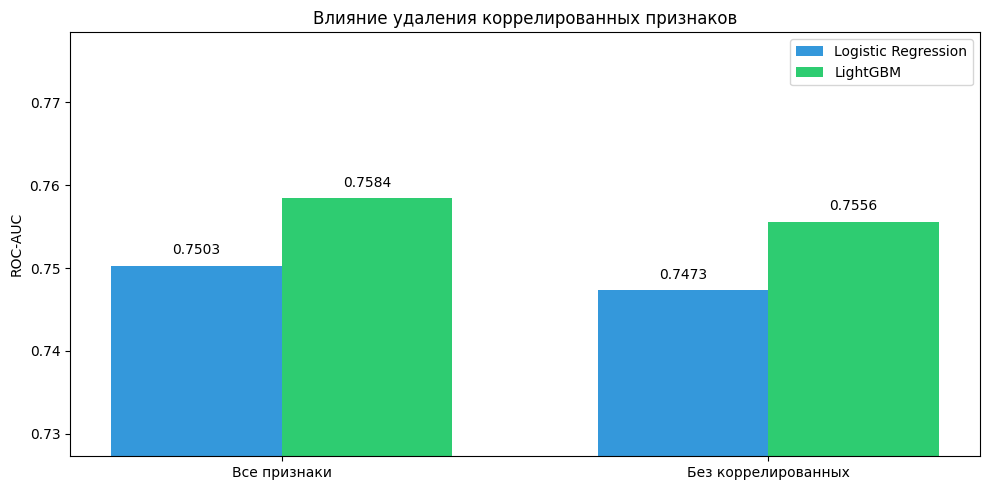

In [13]:
X_train = X_train.rename(columns = lambda x:re.sub('[^A-Za-z0-9_]+', '_', x))
X_val = X_val.rename(columns = lambda x:re.sub('[^A-Za-z0-9_]+', '_', x))

corr_matrix = X_train.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
cols_to_remove = [col for col in upper.columns if any(upper[col] > 0.8)]

X_train_reduced = X_train.drop(columns=cols_to_remove)
X_val_reduced = X_val.drop(columns=cols_to_remove)

print(f"Признаков до удаления: {X_train.shape[1]}")
print(f"Признаков после удаления: {X_train_reduced.shape[1]}")
print(f"Удалено: {len(cols_to_remove)}")

results = []

for name, X_tr, X_v in [('Все признаки', X_train, X_val),
                         ('Без коррелированных', X_train_reduced, X_val_reduced)]:
    lr = LogisticRegression(max_iter=3000, solver='liblinear', class_weight='balanced', random_state=42)
    lr.fit(X_tr, y_train)
    auc = roc_auc_score(y_val, lr.predict_proba(X_v)[:, 1])
    results.append({'Модель': 'Logistic Regression', 'Данные': name, 'ROC-AUC': auc})

for name, X_tr, X_v in [('Все признаки', X_train, X_val),
                         ('Без коррелированных', X_train_reduced, X_val_reduced)]:
    lgb_model = lgb.LGBMClassifier(n_estimators=100, random_state=42, verbose=-1)
    lgb_model.fit(X_tr, y_train)
    auc = roc_auc_score(y_val, lgb_model.predict_proba(X_v)[:, 1])
    results.append({'Модель': 'LightGBM', 'Данные': name, 'ROC-AUC': auc})

results_df = pd.DataFrame(results)
print("\nРезультаты эксперимента:")
print(results_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(2)
width = 0.35

lr_scores = results_df[results_df['Модель'] == 'Logistic Regression']['ROC-AUC'].values
lgb_scores = results_df[results_df['Модель'] == 'LightGBM']['ROC-AUC'].values

bars1 = ax.bar(x - width/2, lr_scores, width, label='Logistic Regression', color='#3498db')
bars2 = ax.bar(x + width/2, lgb_scores, width, label='LightGBM', color='#2ecc71')

ax.set_ylabel('ROC-AUC')
ax.set_title('Влияние удаления коррелированных признаков')
ax.set_xticks(x)
ax.set_xticklabels(['Все признаки', 'Без коррелированных'])
ax.legend()
y_min = min(min(lr_scores), min(lgb_scores)) - 0.02
y_max = max(max(lr_scores), max(lgb_scores)) + 0.02
ax.set_ylim(y_min, y_max)

for bars in [bars1, bars2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{bar.get_height():.4f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

 На практике качество упало, но зато теперь модели будут обучаться быстрее(было удаленно 35 признаков)
 - Logistic Regression:                                           Удаление корреляций может немного улучшить результат, но главная польза - стабильность коэффициентов

- LightGBM:
Удаление корреляций почти не влияет на качество

# 9. Подбор гиперпараметров для lightgbm

Fitting 3 folds for each of 15 candidates, totalling 45 fits

Лучшие параметры: {'colsample_bytree': np.float64(0.7599443886861021), 'learning_rate': np.float64(0.014666566321361544), 'max_depth': 7, 'n_estimators': 463, 'num_leaves': 22, 'reg_alpha': np.float64(0.8599404067363206), 'reg_lambda': np.float64(0.6803075385877797), 'subsample': np.float64(0.7801997007878172)}
Лучший Score на CV (подвыборка): 0.7447
\Итоговый ROC-AUC: 0.7582


<Figure size 1200x1000 with 0 Axes>

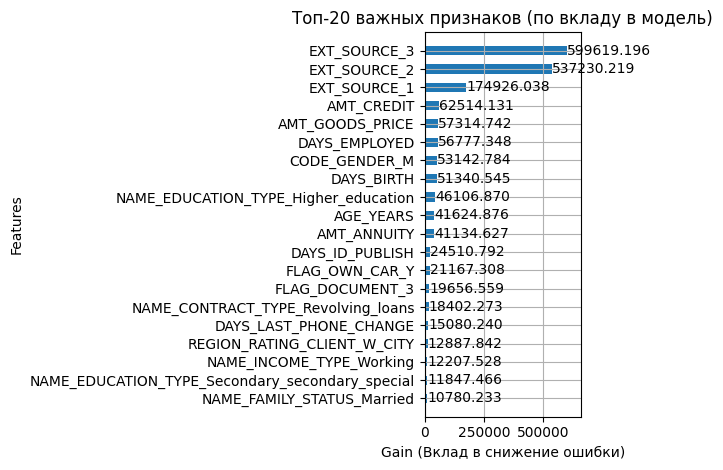

In [14]:
X_train = X_train.rename(columns=lambda x: re.sub('[^A-Za-z0-9_]+', '_', x))
X_val = X_val.rename(columns=lambda x: re.sub('[^A-Za-z0-9_]+', '_', x))

tune_size = int(len(X_train) * 0.3)
X_tune = X_train.iloc[:tune_size]
y_tune = y_train.iloc[:tune_size]

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

lgb_params = {
    'n_estimators': randint(100, 500),
    'learning_rate': uniform(0.01, 0.1),
    'num_leaves': randint(20, 60),
    'max_depth': randint(5, 15),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'reg_alpha': uniform(0, 1),
    'reg_lambda': uniform(0, 1)
}
lgbm = lgb.LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1)

lgb_search = RandomizedSearchCV(
    lgbm, lgb_params, n_iter=15, scoring='roc_auc', cv=cv, verbose=1, random_state=42, n_jobs=-1
)

lgb_search.fit(X_tune, y_tune)

print(f"\nЛучшие параметры: {lgb_search.best_params_}")
print(f"Лучший Score на CV (подвыборка): {lgb_search.best_score_:.4f}")

best_lgbm = lgb_search.best_estimator_
best_lgbm.fit(X_train, y_train)

roc_lgbm = roc_auc_score(y_val, best_lgbm.predict_proba(X_val)[:, 1])

if 'results_comparison' not in locals():
    results_comparison = {}
results_comparison['LightGBM Tuned'] = roc_lgbm

print(f"\Итоговый ROC-AUC: {roc_lgbm:.4f}")

plt.figure(figsize=(12, 10))
lgb.plot_importance(best_lgbm, max_num_features=20, height=0.5,
                    importance_type='gain', title='Топ-20 важных признаков (по вкладу в модель)',
                    xlabel='Gain (Вклад в снижение ошибки)')
plt.tight_layout()
plt.show()

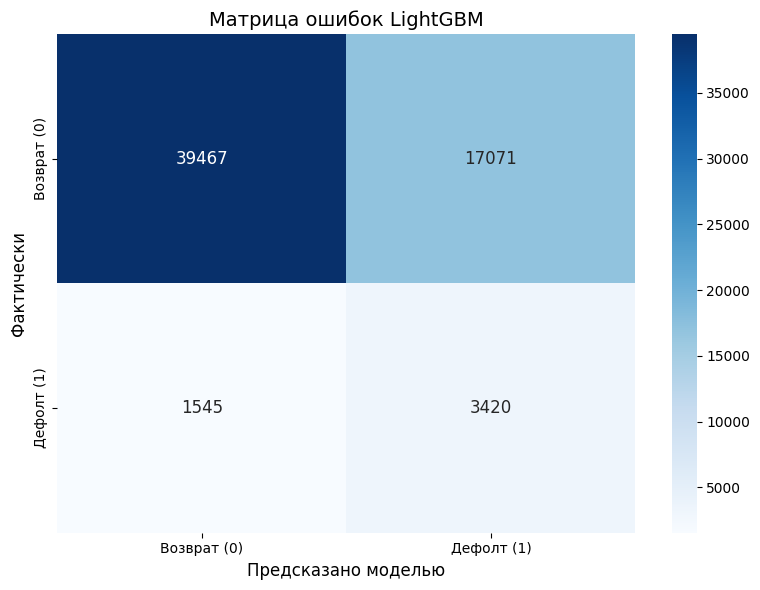

TN:  39,467 (Клиент вернул кредит, модель угадала)
TP:  3,420 (Клиент дефолтнул, модель поймала!)
FP: 17,071 (Ложная тревога: модель отказала хорошему клиенту)
FN: 1,545 (Пропуск дефолта: банк потерял деньги)

Метрики качества:
Recall (Полнота): 68.88% -> Сколько реальных дефолтов мы нашли
Precision (Точность): 16.69% -> Сколько из наших тревог были реальными


In [15]:
y_val_pred = best_lgbm.predict(X_val)
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_val, y_val_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    annot_kws={"size": 12},
    xticklabels=['Возврат (0)', 'Дефолт (1)'],
    yticklabels=['Возврат (0)', 'Дефолт (1)']
)

plt.title('Матрица ошибок LightGBM', fontsize=14)
plt.xlabel('Предсказано моделью', fontsize=12)
plt.ylabel('Фактически', fontsize=12)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()

print(f"TN:  {tn:,} (Клиент вернул кредит, модель угадала)")
print(f"TP:  {tp:,} (Клиент дефолтнул, модель поймала!)")
print(f"FP: {fp:,} (Ложная тревога: модель отказала хорошему клиенту)")
print(f"FN: {fn:,} (Пропуск дефолта: банк потерял деньги)")

precision = tp / (tp + fp)
recall = tp / (tp + fn)
print(f"\nМетрики качества:")
print(f"Recall (Полнота): {recall:.2%} -> Сколько реальных дефолтов мы нашли")
print(f"Precision (Точность): {precision:.2%} -> Сколько из наших тревог были реальными")

# Вывод
   1. Лучшая модель: LightGBM с балансировкой классов (ROC-AUC на тесте 0.7582)
   
   2. Самые важные признаки:
      • EXT_SOURCE_2, EXT_SOURCE_3, EXT_SOURCE_1 (внешние скоринги)

      • Возраст клиента

      • Сумма кредита и аннуитет
   
   3. Несбалансированность классов (92% vs 8%) — главная сложность
      Решение: class_weight='balanced' значительно улучшает Recall
   
   4. Удаление коррелированных признаков:
      
      • Для LightGBM — не обязательно

      • Для Logistic Regression — желательно

      в теории, но на конкретно этом датасете не работает